# SquareOscillator Strategies

This notebook demonstrates the square wave generation algorithms available in AudioPlayground. Each strategy produces a different character of square wave, from ideal aliased edges to PolyBLEP antialiasing, VCV Rack-style minBLEP correction, and analog-style comparator behavior.

Available strategies:
- **ideal**: Traditional square wave with instant transitions (aliasing present)
- **ideal_smooth**: Ideal square wave with internal amplitude smoothing for click-free gain changes
- **bandlimited**: PolyBLEP antialiased square wave (professional quality)
- **vcv**: VCV Rack Fundamental-style minBLEP square with DC blocking
- **soft**: Smooth transitions using tanh() (warm, analog-style)
- **comparator**: Sine comparator with hysteresis (analog circuit emulation)


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from engine import SquareOscillator

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (14, 10)

## 1. Ideal Square Wave (Default)

The traditional square wave with instant transitions. This is the fastest algorithm
but produces aliasing at high frequencies. Perfect for retro sounds and low frequencies.

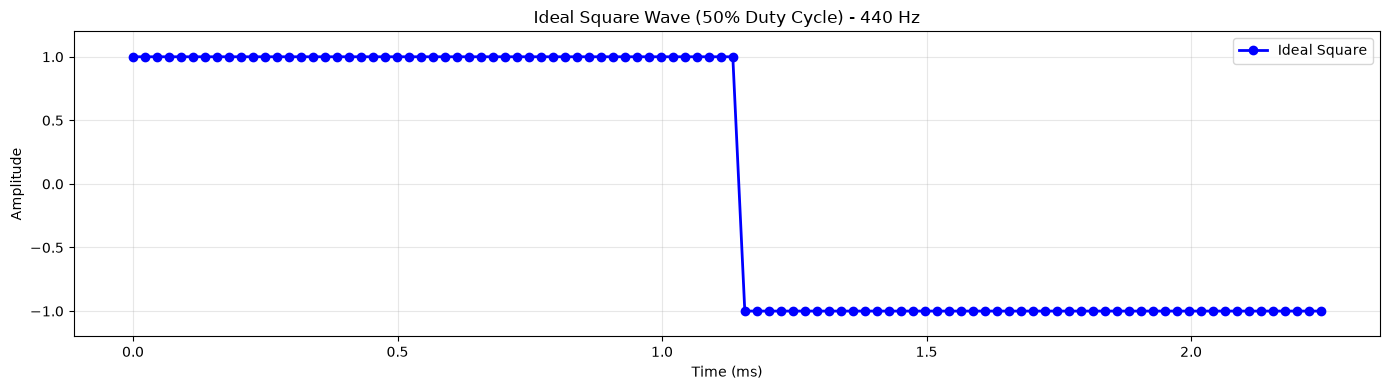

OK Ideal square wave: instant transitions, classic square wave sound
  Min: -1.000, Max: 1.000
  Transitions: Instantaneous (may cause aliasing)


In [2]:
# Create ideal square wave oscillator
osc_ideal = SquareOscillator(frequency=440, mode="ideal", pulsewidth=0.5, gain_db=0)

# Generate one period
sample_rate = 44100
period_samples = int(sample_rate / 440)
samples_ideal = osc_ideal.get_samples(period_samples)

# Plot waveform
time = np.arange(period_samples) / sample_rate * 1000  # in milliseconds

plt.subplots(figsize=(14, 4))
plt.plot(time, samples_ideal, "b-", marker="o", linewidth=2, label="Ideal Square")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ideal Square Wave (50% Duty Cycle) - 440 Hz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()

print("OK Ideal square wave: instant transitions, classic square wave sound")
print(f"  Min: {samples_ideal.min():.3f}, Max: {samples_ideal.max():.3f}")
print("  Transitions: Instantaneous (may cause aliasing)")

## 2. Ideal Smooth Square Wave

Uses the same square edges as `ideal`, but owns an internal amplitude ramp. This is useful when changing gain or amplitude during playback because the transition is spread over a configurable number of milliseconds.


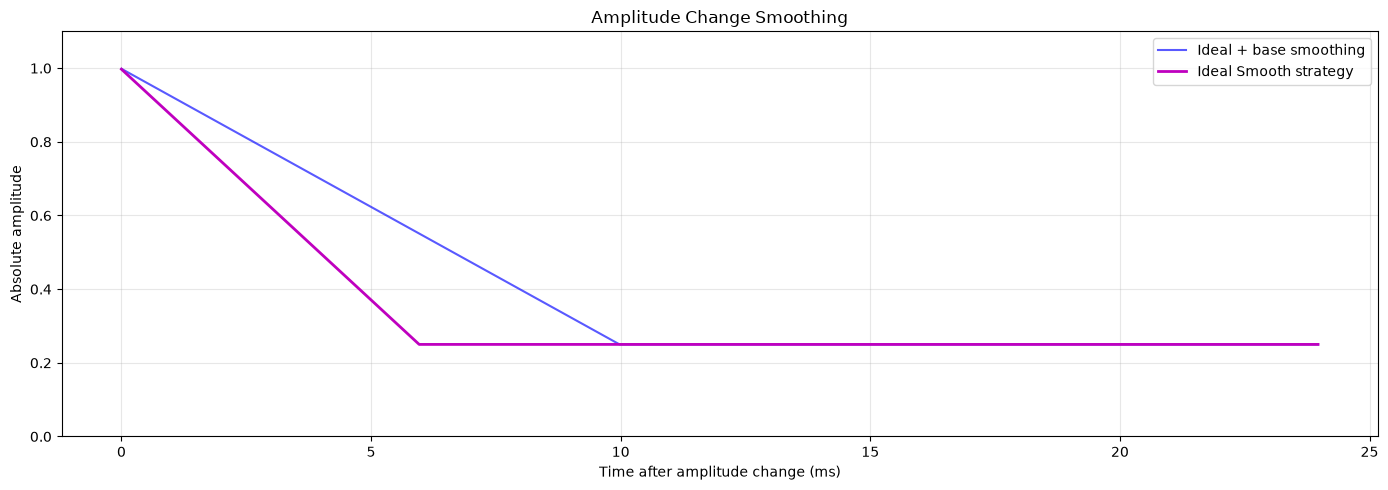

OK ideal_smooth: ideal square wave with strategy-owned amplitude smoothing
  Final absolute amplitude: 0.250
  Use smoothing_time_ms to control the ramp duration


In [13]:
# Demonstrate internal amplitude smoothing
osc_ideal_step = SquareOscillator(
    frequency=440,
    mode="ideal",
    amplitude=1.0,
    gain_db=None,
    sample_rate=sample_rate,
)
osc_ideal_smooth = SquareOscillator(
    frequency=440,
    mode="ideal_smooth",
    amplitude=1.0,
    gain_db=None,
    sample_rate=sample_rate,
    smoothing_time_ms=6.0,
)

# Complete construction-time smoothing so the comparison starts from a steady amplitude
osc_ideal_step.get_samples(int(sample_rate * 0.02))
osc_ideal_smooth.get_samples(int(sample_rate * 0.02))

osc_ideal_step.amplitude = 0.25
osc_ideal_smooth.amplitude = 0.25

ramp_samples = int(sample_rate * 0.012)
samples_ideal_step = osc_ideal_step.get_samples(ramp_samples)
samples_ideal_smooth = osc_ideal_smooth.get_samples(ramp_samples)
ramp_time = np.arange(ramp_samples) / sample_rate * 1000

plt.subplots(figsize=(14, 5))
plt.plot(
    ramp_time,
    np.abs(samples_ideal_step),
    "b-",
    alpha=0.65,
    label="Ideal + base smoothing",
)
plt.plot(
    ramp_time,
    np.abs(samples_ideal_smooth),
    "m-",
    linewidth=2,
    label="Ideal Smooth strategy",
)
plt.xlabel("Time after amplitude change (ms)")
plt.ylabel("Absolute amplitude")
plt.title("Amplitude Change Smoothing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

print("OK ideal_smooth: ideal square wave with strategy-owned amplitude smoothing")
print(f"  Final absolute amplitude: {np.abs(samples_ideal_smooth[-1]):.3f}")
print("  Use smoothing_time_ms to control the ramp duration")

## 3. Bandlimited Square Wave

Uses PolyBLEP (Polynomial Band-Limited Step) correction to reduce aliasing at discontinuities. This produces a cleaner square wave suitable for higher frequencies.


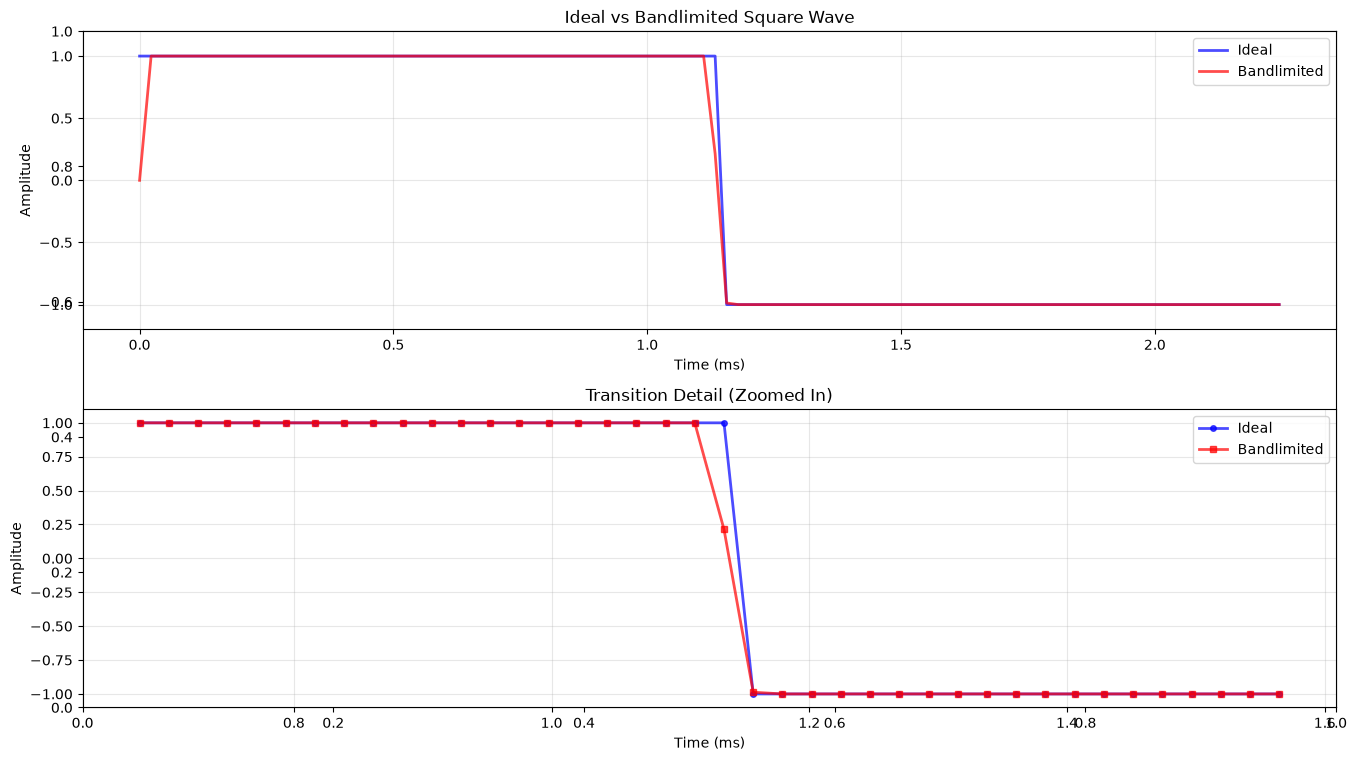

OK Bandlimited square wave: smooth transitions reduce aliasing
  Min: -1.000, Max: 1.000
  Transitions: Smoothed with PolyBLEP correction


In [4]:
# Create bandlimited square wave oscillator
osc_bandlimited = SquareOscillator(
    frequency=440, mode="bandlimited", pulsewidth=0.5, gain_db=0
)

# Generate one period
samples_bandlimited = osc_bandlimited.get_samples(period_samples)

# Plot comparison with ideal
plt.subplots(figsize=(14, 8))

# Full waveform comparison
plt.subplot(2, 1, 1)
plt.plot(time, samples_ideal, "b-", linewidth=2, alpha=0.7, label="Ideal")
plt.plot(time, samples_bandlimited, "r-", linewidth=2, alpha=0.7, label="Bandlimited")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ideal vs Bandlimited Square Wave")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.2, 1.2)

# Zoom in on transition
plt.subplot(2, 1, 2)
transition_start = period_samples // 2 - 20
transition_end = period_samples // 2 + 20
zoom_time = time[transition_start:transition_end]
plt.plot(
    zoom_time,
    samples_ideal[transition_start:transition_end],
    "b-",
    linewidth=2,
    marker="o",
    markersize=4,
    alpha=0.7,
    label="Ideal",
)
plt.plot(
    zoom_time,
    samples_bandlimited[transition_start:transition_end],
    "r-",
    linewidth=2,
    marker="s",
    markersize=4,
    alpha=0.7,
    label="Bandlimited",
)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Transition Detail (Zoomed In)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("OK Bandlimited square wave: smooth transitions reduce aliasing")
print(f"  Min: {samples_bandlimited.min():.3f}, Max: {samples_bandlimited.max():.3f}")
print("  Transitions: Smoothed with PolyBLEP correction")

## 4. minBLEP Square Wave (VCV Rack-Style)

Uses a VCV Rack Fundamental-inspired square oscillator strategy: minBLEP edge correction, 1%-99% pulse-width clamping, and a one-pole high-pass/DC-blocking filter. The minBLEP correction produces small edge ringing, which is expected and visible around transitions.


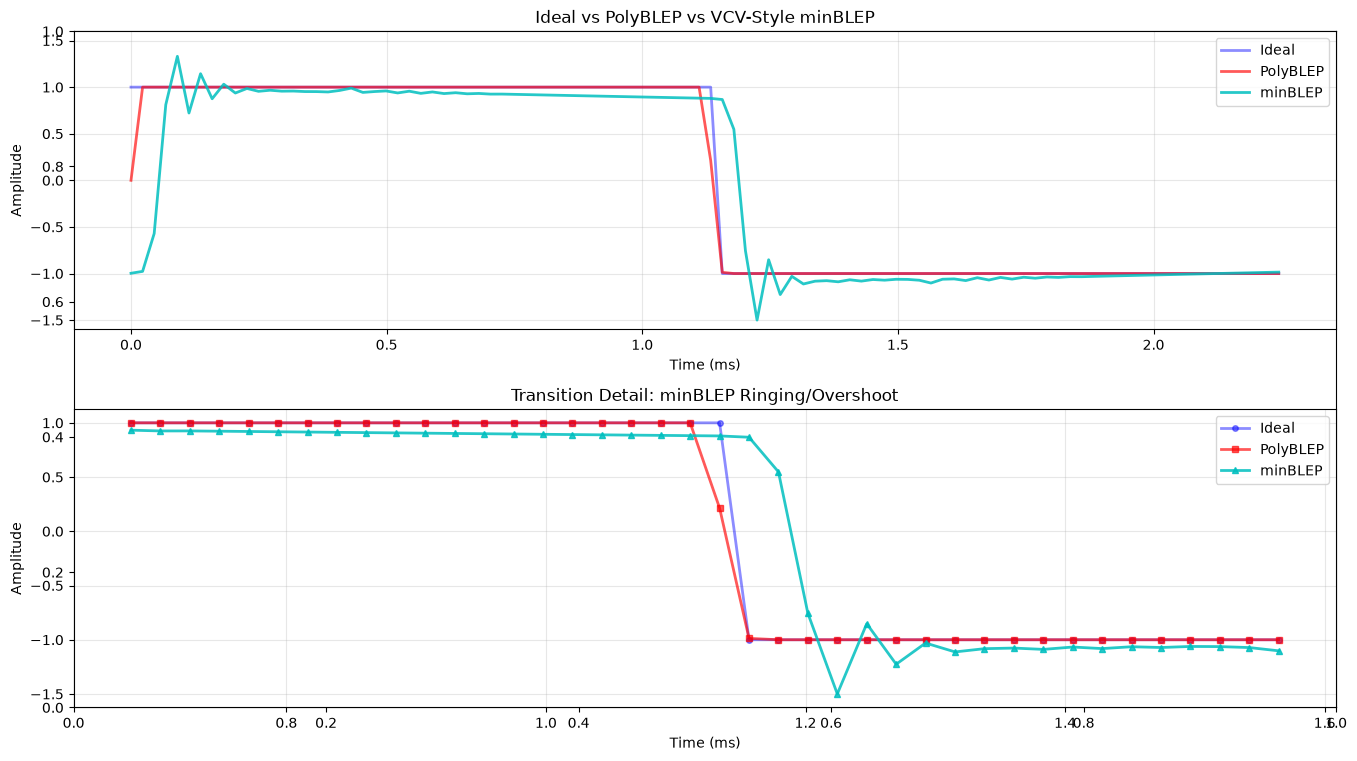

OK VCV Rack-style square wave: minBLEP correction with DC blocking
  Min: -1.500, Max: 1.331
  Pulse width is internally clamped to 1%-99%, matching VCV Rack behavior


In [5]:
# Create VCV Rack-style square wave oscillator
osc_vcv = SquareOscillator(frequency=440, mode="vcv", pulsewidth=0.5, gain_db=0)

samples_vcv = osc_vcv.get_samples(period_samples)

plt.subplots(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(time, samples_ideal, "b-", linewidth=2, alpha=0.45, label="Ideal")
plt.plot(time, samples_bandlimited, "r-", linewidth=2, alpha=0.65, label="PolyBLEP")
plt.plot(time, samples_vcv, "c-", linewidth=2, alpha=0.85, label="minBLEP")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Ideal vs PolyBLEP vs VCV-Style minBLEP")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.6, 1.6)

plt.subplot(2, 1, 2)
transition_start = period_samples // 2 - 20
transition_end = period_samples // 2 + 20
zoom_time = time[transition_start:transition_end]
plt.plot(
    zoom_time,
    samples_ideal[transition_start:transition_end],
    "b-",
    linewidth=2,
    marker="o",
    markersize=4,
    alpha=0.45,
    label="Ideal",
)
plt.plot(
    zoom_time,
    samples_bandlimited[transition_start:transition_end],
    "r-",
    linewidth=2,
    marker="s",
    markersize=4,
    alpha=0.65,
    label="PolyBLEP",
)
plt.plot(
    zoom_time,
    samples_vcv[transition_start:transition_end],
    "c-",
    linewidth=2,
    marker="^",
    markersize=4,
    alpha=0.85,
    label="minBLEP",
)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Transition Detail: minBLEP Ringing/Overshoot")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("OK VCV Rack-style square wave: minBLEP correction with DC blocking")
print(f"  Min: {samples_vcv.min():.3f}, Max: {samples_vcv.max():.3f}")
print("  Pulse width is internally clamped to 1%-99%, matching VCV Rack behavior")

## 5. Soft Square Wave

Uses hyperbolic tangent (tanh) for smooth transitions. Creates a warmer, more analog-style sound with reduced aliasing. The `smoothness` parameter controls how sharp the transitions are (1.0 = very soft, 100.0 = nearly ideal).


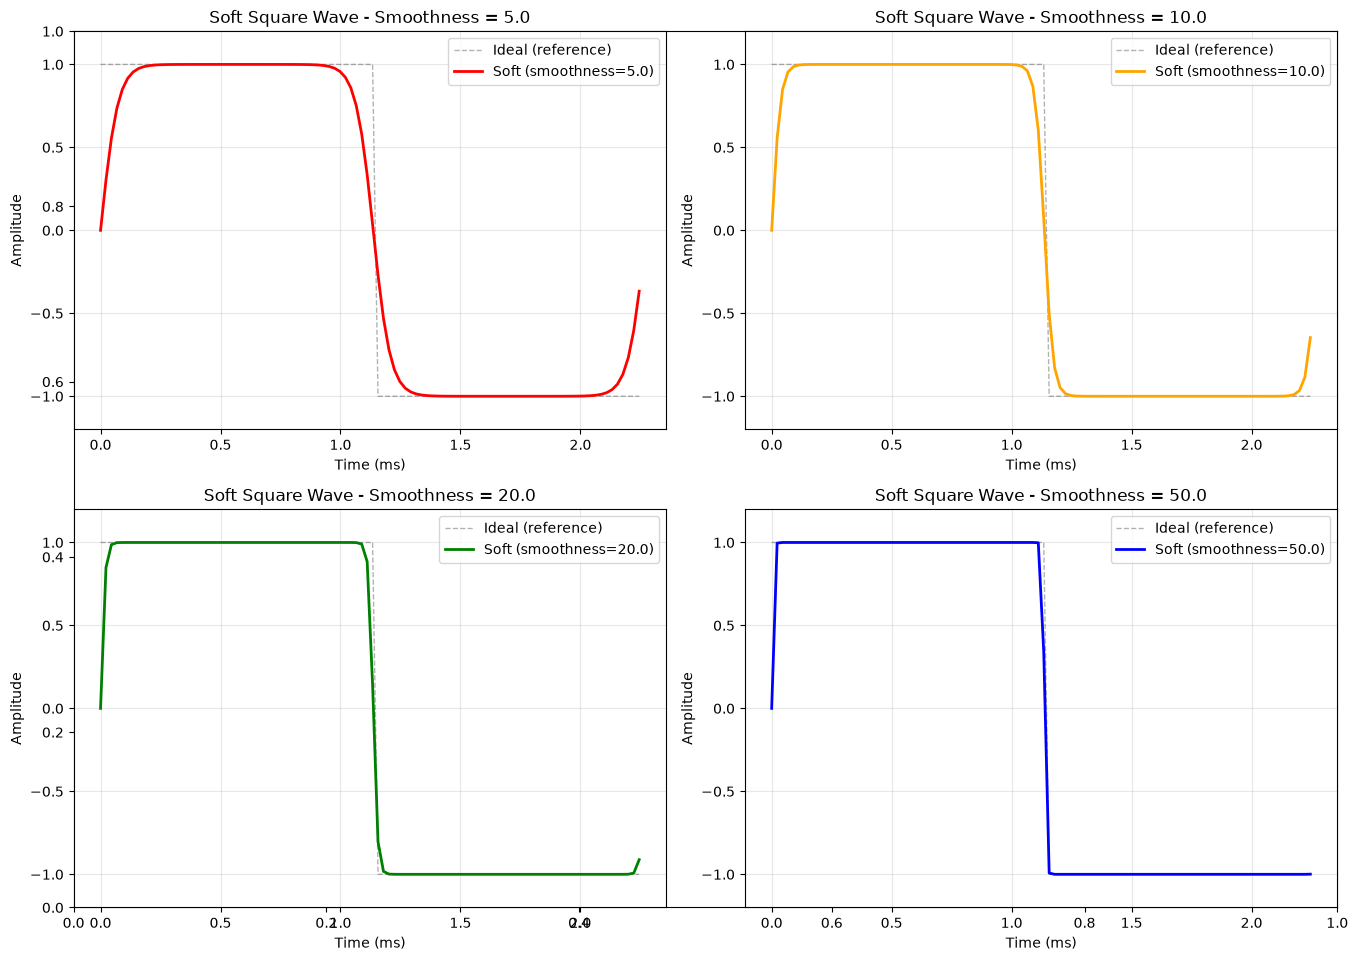

OK Soft square waves: smooth transitions using tanh()
  Lower smoothness = softer, warmer sound
  Higher smoothness = sharper, closer to ideal


In [6]:
# Create soft square wave oscillators with different smoothness values
smoothness_values = [5.0, 10.0, 20.0, 50.0]
colors = ["red", "orange", "green", "blue"]

plt.subplots(figsize=(14, 10))

# Plot each smoothness value
for idx, (smoothness, color) in enumerate(zip(smoothness_values, colors, strict=False)):
    osc_soft = SquareOscillator(
        frequency=440, mode="soft", smoothness=smoothness, pulsewidth=0.5, gain_db=0
    )
    samples_soft = osc_soft.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(
        time, samples_ideal, "k--", linewidth=1, alpha=0.3, label="Ideal (reference)"
    )
    plt.plot(
        time,
        samples_soft,
        color=color,
        linewidth=2,
        label=f"Soft (smoothness={smoothness})",
    )
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Soft Square Wave - Smoothness = {smoothness}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("OK Soft square waves: smooth transitions using tanh()")
print("  Lower smoothness = softer, warmer sound")
print("  Higher smoothness = sharper, closer to ideal")

## 6. Comparator Square Wave

Simulates a hardware comparator circuit with hysteresis. This creates an analog-style square wave with characteristic behavior near the transitions. The `hysteresis` parameter controls the switching margin (0.0 = no hysteresis, 0.1 = 10%).


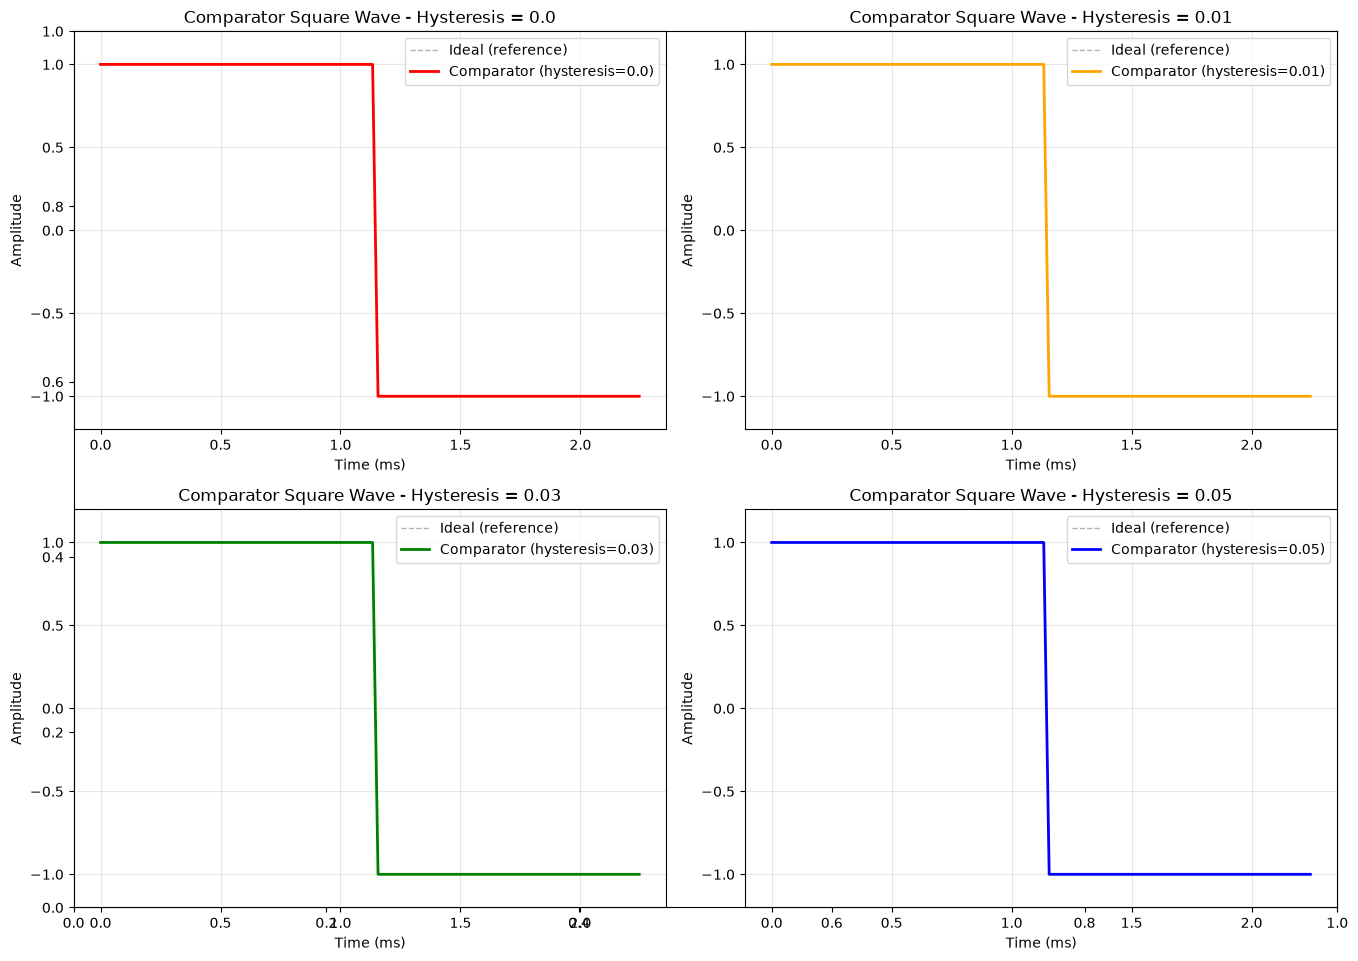

OK Comparator square waves: analog circuit emulation
  Hysteresis creates stable transitions
  Higher hysteresis = more stable, smoother transitions


In [7]:
# Create comparator square wave oscillators with different hysteresis values
hysteresis_values = [0.0, 0.01, 0.03, 0.05]
colors = ["red", "orange", "green", "blue"]

plt.subplots(figsize=(14, 10))

# Plot each hysteresis value
for idx, (hysteresis, color) in enumerate(zip(hysteresis_values, colors, strict=False)):
    osc_comp = SquareOscillator(
        frequency=440,
        mode="comparator",
        hysteresis=hysteresis,
        pulsewidth=0.5,
        gain_db=0,
    )
    samples_comp = osc_comp.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(
        time, samples_ideal, "k--", linewidth=1, alpha=0.3, label="Ideal (reference)"
    )
    plt.plot(
        time,
        samples_comp,
        color=color,
        linewidth=2,
        label=f"Comparator (hysteresis={hysteresis})",
    )
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Comparator Square Wave - Hysteresis = {hysteresis}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(-1.2, 1.2)

plt.tight_layout()
plt.show()

print("OK Comparator square waves: analog circuit emulation")
print("  Hysteresis creates stable transitions")
print("  Higher hysteresis = more stable, smoother transitions")

## 7. Pulse Width Modulation (PWM)

All strategies support variable pulse width. Let's demonstrate different duty cycles.


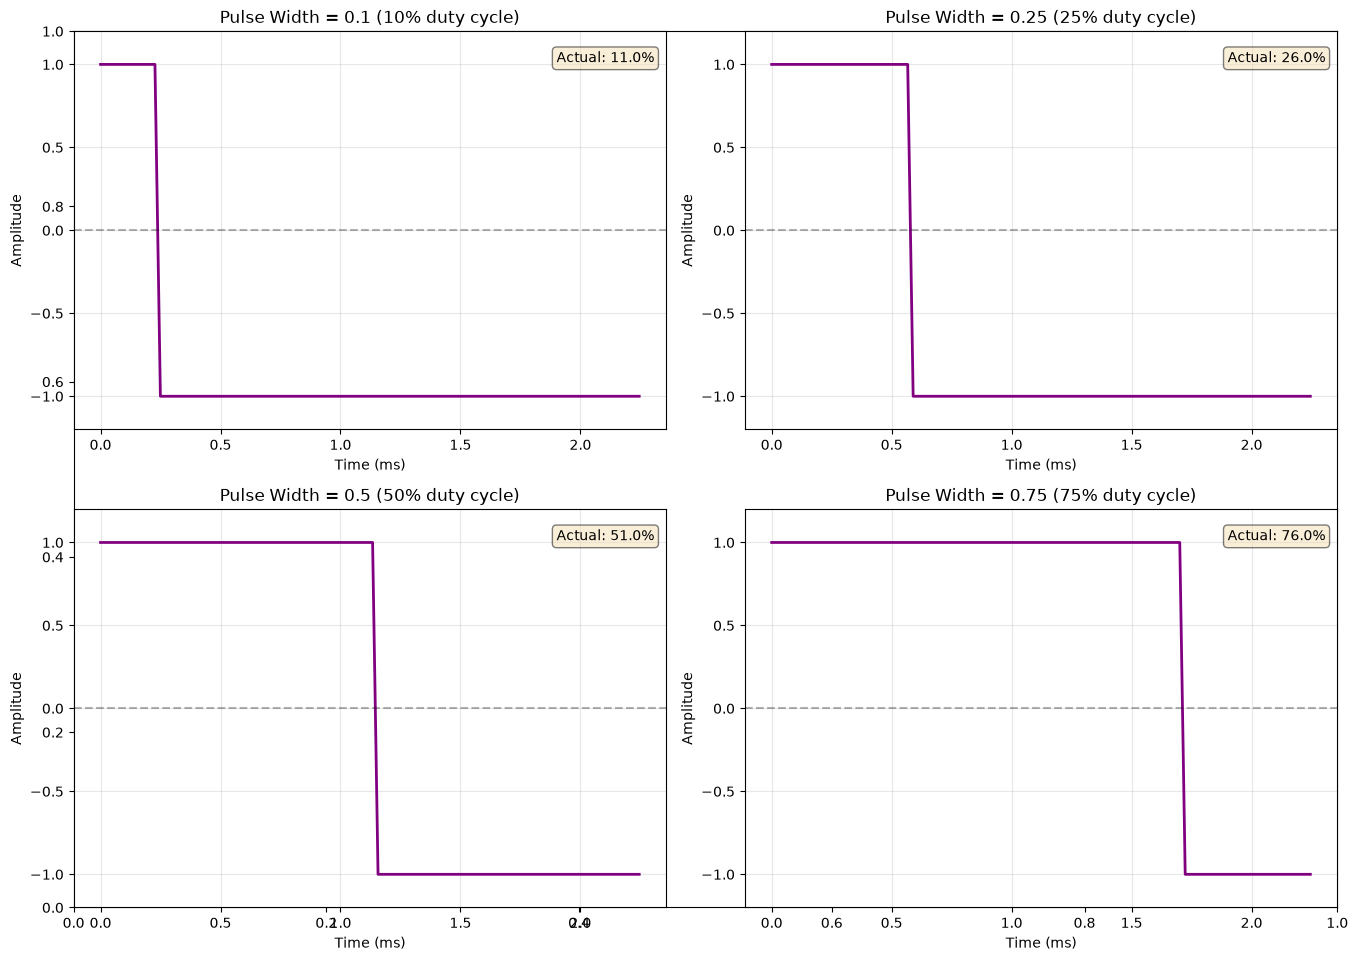

OK Pulse width modulation: duty cycle from 0% to 100%
  0.5 = traditional square wave (50%)
  < 0.5 = narrow pulse
  > 0.5 = wide pulse


In [8]:
pulsewidths = [0.1, 0.25, 0.5, 0.75]
duty_cycle_labels = ["10%", "25%", "50%", "75%"]

plt.subplots(figsize=(14.0, 10.0))

for idx, (pw, label) in enumerate(zip(pulsewidths, duty_cycle_labels, strict=False)):
    # Use ideal for clarity
    osc_pwm = SquareOscillator(frequency=440, mode="ideal", pulsewidth=pw, gain_db=0)
    samples_pwm = osc_pwm.get_samples(period_samples)

    plt.subplot(2, 2, idx + 1)
    plt.plot(time, samples_pwm, "purple", linewidth=2)
    plt.axhline(y=0, color="k", linestyle="--", alpha=0.3)
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(f"Pulse Width = {pw} ({label} duty cycle)")
    plt.grid(True, alpha=0.3)
    plt.ylim(-1.2, 1.2)

    # Add duty cycle indicator
    high_samples = np.sum(samples_pwm > 0)
    actual_duty = high_samples / len(samples_pwm) * 100
    plt.text(
        0.98,
        0.95,
        f"Actual: {actual_duty:.1f}%",
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.show()

print("OK Pulse width modulation: duty cycle from 0% to 100%")
print("  0.5 = traditional square wave (50%)")
print("  < 0.5 = narrow pulse")
print("  > 0.5 = wide pulse")

## 8. Strategy Comparison at High Frequency

At higher frequencies, the differences between strategies become more apparent. Aliasing is more noticeable with the ideal square wave, while `bandlimited`, `vcv`, and `soft` reduce edge energy in different ways.


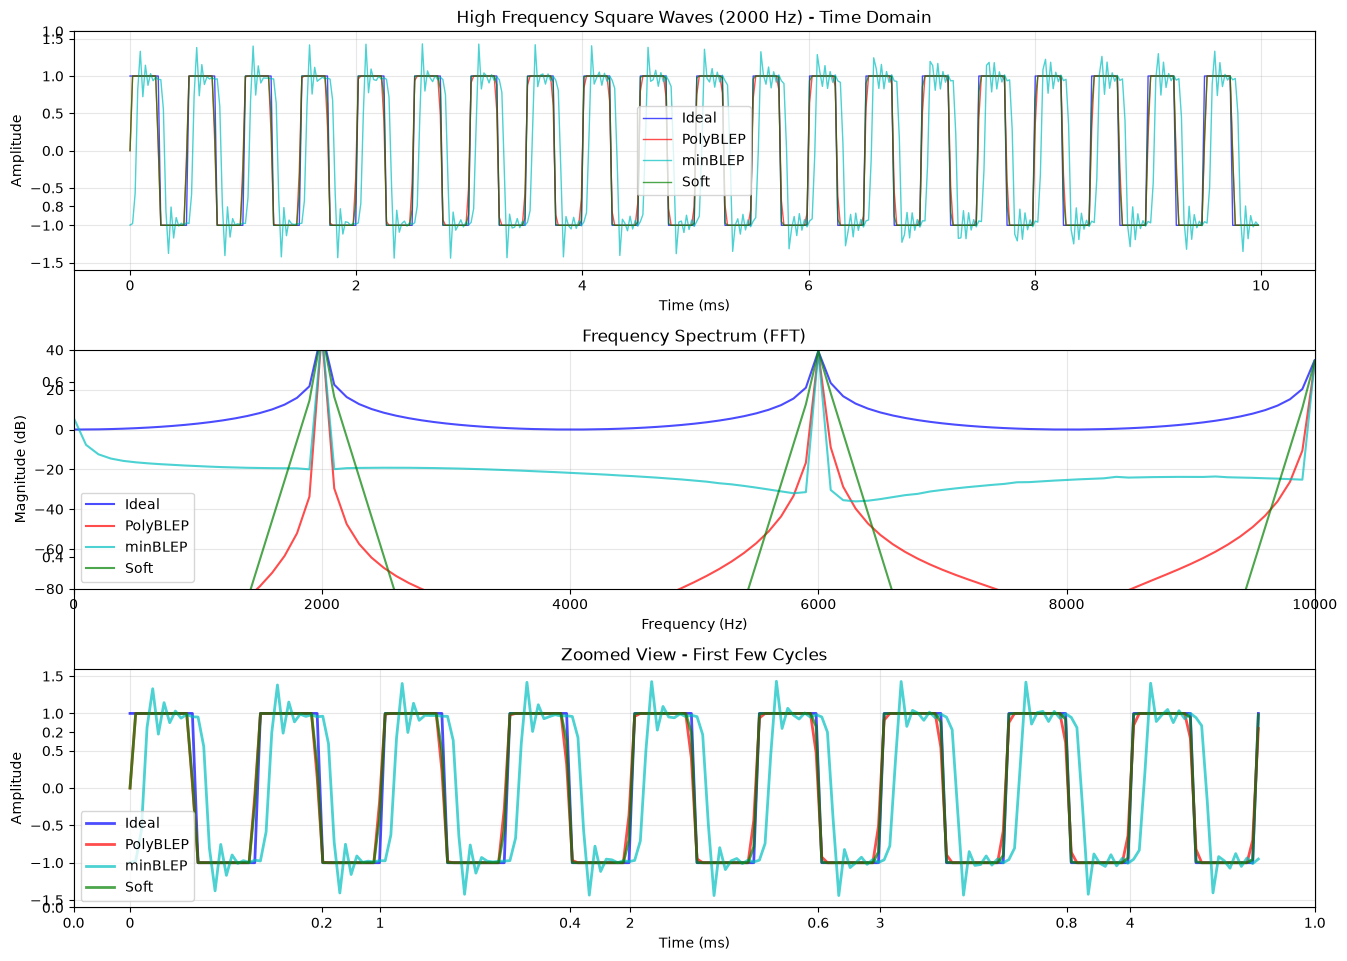

OK High frequency comparison (2000 Hz):
  Ideal: Sharp harmonics, potential aliasing
  PolyBLEP: Reduced high-frequency aliasing
  minBLEP: VCV-style ringing plus DC blocking
  Soft: Reduced high-frequency content, warm sound


In [9]:
# Generate high frequency square waves (2 kHz)
high_freq = 2000
osc_ideal_hf = SquareOscillator(frequency=high_freq, mode="ideal", gain_db=0)
osc_bandlimited_hf = SquareOscillator(
    frequency=high_freq, mode="bandlimited", gain_db=0
)
osc_vcv_hf = SquareOscillator(frequency=high_freq, mode="vcv", gain_db=0)
osc_soft_hf = SquareOscillator(
    frequency=high_freq, mode="soft", smoothness=15.0, gain_db=0
)

# Generate samples
n_samples = int(sample_rate * 0.01)  # 10ms
samples_ideal_hf = osc_ideal_hf.get_samples(n_samples)
samples_bandlimited_hf = osc_bandlimited_hf.get_samples(n_samples)
samples_vcv_hf = osc_vcv_hf.get_samples(n_samples)
samples_soft_hf = osc_soft_hf.get_samples(n_samples)

time_hf = np.arange(n_samples) / sample_rate * 1000

plt.subplots(figsize=(14.0, 10.0))

# Time domain comparison
plt.subplot(3, 1, 1)
plt.plot(time_hf, samples_ideal_hf, "b-", linewidth=1, alpha=0.7, label="Ideal")
plt.plot(
    time_hf, samples_bandlimited_hf, "r-", linewidth=1, alpha=0.7, label="PolyBLEP"
)
plt.plot(time_hf, samples_vcv_hf, "c-", linewidth=1, alpha=0.7, label="minBLEP")
plt.plot(time_hf, samples_soft_hf, "g-", linewidth=1, alpha=0.7, label="Soft")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title(f"High Frequency Square Waves ({high_freq} Hz) - Time Domain")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.6, 1.6)

# Frequency spectrum (FFT) comparison
plt.subplot(3, 1, 2)
fft_ideal = np.fft.rfft(samples_ideal_hf)
fft_bandlimited = np.fft.rfft(samples_bandlimited_hf)
fft_vcv = np.fft.rfft(samples_vcv_hf)
fft_soft = np.fft.rfft(samples_soft_hf)
freqs = np.fft.rfftfreq(n_samples, 1 / sample_rate)

plt.plot(
    freqs, 20 * np.log10(np.abs(fft_ideal) + 1e-10), "b-", alpha=0.7, label="Ideal"
)
plt.plot(
    freqs,
    20 * np.log10(np.abs(fft_bandlimited) + 1e-10),
    "r-",
    alpha=0.7,
    label="PolyBLEP",
)
plt.plot(
    freqs, 20 * np.log10(np.abs(fft_vcv) + 1e-10), "c-", alpha=0.7, label="minBLEP"
)
plt.plot(freqs, 20 * np.log10(np.abs(fft_soft) + 1e-10), "g-", alpha=0.7, label="Soft")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Spectrum (FFT)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, 10000)
plt.ylim(-80, 40)

# Zoom on a few cycles
plt.subplot(3, 1, 3)
zoom_samples = 200
plt.plot(
    time_hf[:zoom_samples],
    samples_ideal_hf[:zoom_samples],
    "b-",
    linewidth=2,
    alpha=0.7,
    label="Ideal",
)
plt.plot(
    time_hf[:zoom_samples],
    samples_bandlimited_hf[:zoom_samples],
    "r-",
    linewidth=2,
    alpha=0.7,
    label="PolyBLEP",
)
plt.plot(
    time_hf[:zoom_samples],
    samples_vcv_hf[:zoom_samples],
    "c-",
    linewidth=2,
    alpha=0.7,
    label="minBLEP",
)
plt.plot(
    time_hf[:zoom_samples],
    samples_soft_hf[:zoom_samples],
    "g-",
    linewidth=2,
    alpha=0.7,
    label="Soft",
)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Zoomed View - First Few Cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.6, 1.6)

plt.tight_layout()
plt.show()

print(f"OK High frequency comparison ({high_freq} Hz):")
print("  Ideal: Sharp harmonics, potential aliasing")
print("  PolyBLEP: Reduced high-frequency aliasing")
print("  minBLEP: VCV-style ringing plus DC blocking")
print("  Soft: Reduced high-frequency content, warm sound")

## 9. Runtime Mode Switching

You can change the square wave generation algorithm without recreating the oscillator.


OK Runtime mode switching demonstration:
  Mode: ideal        - Min: -1.000, Max:  1.000
  Mode: ideal_smooth - Min: -1.000, Max:  1.000
  Mode: bandlimited  - Min: -1.000, Max:  1.000
  Mode: vcv          - Min: -1.500, Max:  1.331
  Mode: soft         - Min: -1.000, Max:  1.000
  Mode: comparator   - Min: -1.000, Max:  1.000


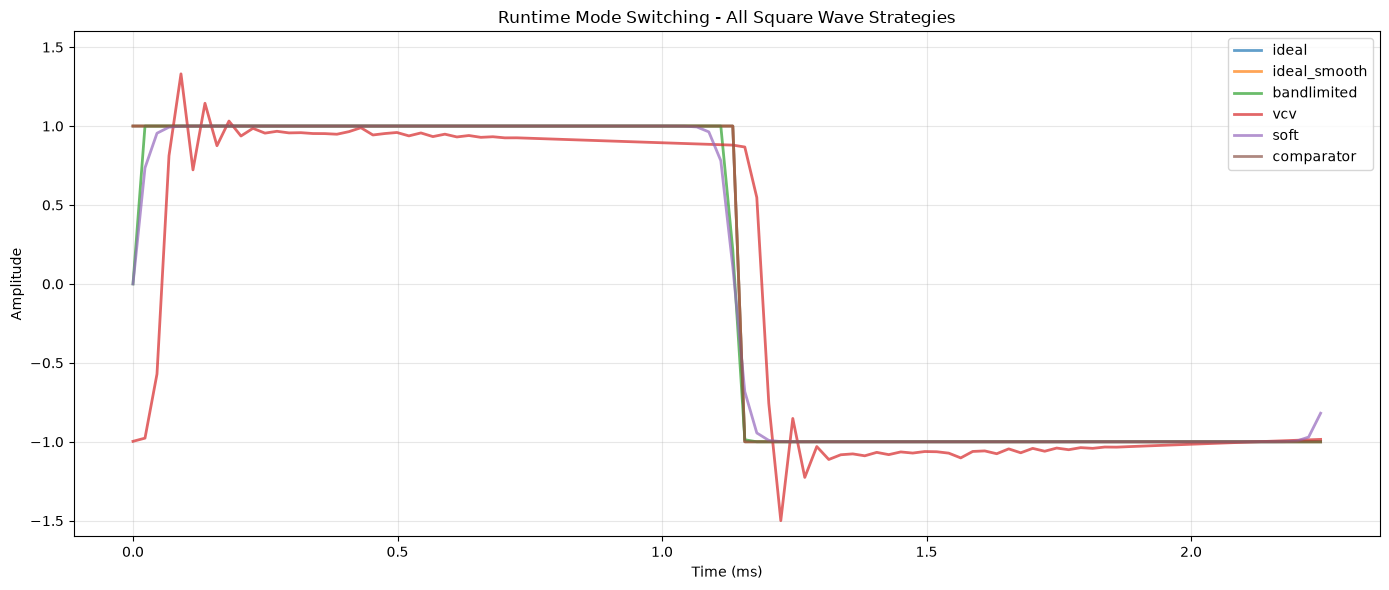

In [10]:
# Create oscillator with one mode
osc_switchable = SquareOscillator(
    frequency=440, mode="ideal", pulsewidth=0.5, gain_db=0
)

print("OK Runtime mode switching demonstration:")

# Generate samples with different modes
modes = ["ideal", "ideal_smooth", "bandlimited", "vcv", "soft", "comparator"]
mode_samples = {}
mode_kwargs = {
    "ideal": {},
    "ideal_smooth": {"smoothing_time_ms": 6.0},
    "bandlimited": {},
    "vcv": {},
    "soft": {"smoothness": 15.0},
    "comparator": {"hysteresis": 0.02},
}

for mode in modes:
    osc_switchable.set_mode(mode, **mode_kwargs[mode])

    # Reset phase and any stateful strategy internals for consistent comparison
    iter(osc_switchable)
    mode_samples[mode] = osc_switchable.get_samples(period_samples)
    print(
        f"  Mode: {mode:12s} - "
        f"Min: {mode_samples[mode].min():6.3f}, "
        f"Max: {mode_samples[mode].max():6.3f}"
    )

# Plot all modes
plt.subplots(figsize=(14.0, 6.0))
colors = ["blue", "magenta", "red", "cyan", "green", "purple"]
for mode, _ in zip(modes, colors, strict=False):
    plt.plot(time, mode_samples[mode], linewidth=2, alpha=0.7, label=mode)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Runtime Mode Switching - All Square Wave Strategies")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-1.6, 1.6)
plt.tight_layout()
plt.show()

## 10. Available Modes

Query the oscillator for available square wave generation modes.


In [11]:
available_modes = SquareOscillator.get_available_modes()

mode_details = {
    "ideal": "Traditional square wave with instant transitions",
    "ideal_smooth": "Ideal square wave with internal amplitude smoothing",
    "bandlimited": "PolyBLEP antialiased square wave",
    "vcv": "VCV Rack-style minBLEP square with DC blocking",
    "soft": "Smooth transitions using tanh()",
    "comparator": "Sine comparator with hysteresis",
}

print("Available square wave generation modes:")
print("=" * 60)
for mode in available_modes:
    print(f"  - {mode}")

print("\nMode details:")
print("-" * 60)
for mode in available_modes:
    print(f"{mode:14s}: {mode_details.get(mode, 'Custom registered strategy')}")

Available square wave generation modes:
  - ideal
  - ideal_smooth
  - bandlimited
  - vcv
  - soft
  - comparator

Mode details:
------------------------------------------------------------
ideal         : Traditional square wave with instant transitions
ideal_smooth  : Ideal square wave with internal amplitude smoothing
bandlimited   : PolyBLEP antialiased square wave
vcv           : VCV Rack-style minBLEP square with DC blocking
soft          : Smooth transitions using tanh()
comparator    : Sine comparator with hysteresis


## 11. Strategy Characteristics Summary


In [12]:
summary_rows = [
    ("Ideal", "1/5", "3/5", "High", "Sharp, digital", "Retro, low freq", "None"),
    (
        "Ideal Smooth",
        "1/5",
        "3/5",
        "High",
        "Sharp, click-safe gain",
        "Live parameter changes",
        "smoothing_time_ms",
    ),
    (
        "PolyBLEP",
        "3/5",
        "5/5",
        "Low",
        "Clean, professional",
        "High-quality synthesis",
        "sample_rate/frequency auto",
    ),
    (
        "MinBLEP",
        "4/5",
        "5/5",
        "Low",
        "minBLEP with ringing",
        "VCV-like tone",
        "dc_block",
    ),
    ("Soft", "2/5", "4/5", "Low", "Warm, analog", "Analog-style", "smoothness"),
    (
        "Comparator",
        "2/5",
        "3/5",
        "Medium",
        "Analog circuit",
        "Circuit modeling",
        "hysteresis",
    ),
]
headers = (
    "Strategy",
    "CPU Cost",
    "Quality",
    "Aliasing",
    "Sound Character",
    "Best For",
    "Parameters",
)
widths = [
    max(len(str(row[i])) for row in [headers, *summary_rows])
    for i in range(len(headers))
]

print("\nSquare Wave Strategy Comparison")
print("=" * 120)
print(" | ".join(str(value).ljust(widths[i]) for i, value in enumerate(headers)))
print("-" * 120)
for row in summary_rows:
    print(" | ".join(str(value).ljust(widths[i]) for i, value in enumerate(row)))


Square Wave Strategy Comparison
Strategy     | CPU Cost | Quality | Aliasing | Sound Character        | Best For               | Parameters                
------------------------------------------------------------------------------------------------------------------------
Ideal        | 1/5      | 3/5     | High     | Sharp, digital         | Retro, low freq        | None                      
Ideal Smooth | 1/5      | 3/5     | High     | Sharp, click-safe gain | Live parameter changes | smoothing_time_ms         
PolyBLEP     | 3/5      | 5/5     | Low      | Clean, professional    | High-quality synthesis | sample_rate/frequency auto
MinBLEP      | 4/5      | 5/5     | Low      | minBLEP with ringing   | VCV-like tone          | dc_block                  
Soft         | 2/5      | 4/5     | Low      | Warm, analog           | Analog-style           | smoothness                
Comparator   | 2/5      | 3/5     | Medium   | Analog circuit         | Circuit modeling       | hyste

## Conclusion

AudioPlayground provides six square wave generation strategies:

1. **Ideal** - Fast, classic square wave with aliasing (default)
2. **Ideal Smooth** - Ideal waveform with internal amplitude smoothing
3. **Bandlimited** - Cleaner high-frequency square waves using PolyBLEP
4. **VCV-style** - VCV Rack Fundamental-inspired minBLEP with DC blocking
5. **Soft** - Warm, analog-style transitions with configurable smoothness
6. **Comparator** - Analog circuit emulation with hysteresis

Each strategy is optimized for different use cases and can be switched at runtime. Use the `mode` parameter in the constructor or `set_mode()` method to switch strategies.

**Try it yourself:**
```python
osc = SquareOscillator(frequency=440, mode="vcv")
osc.set_mode("soft", smoothness=15.0)
samples = osc.get_samples(44100)
```
